<a href="https://colab.research.google.com/github/rodrigoviannasn/MAT-422/blob/main/MAT422_HW_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 — Homework 1.4: Singular Value Decomposition and PCA
Rodrigo Vianna | 9/13/2026

In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Singular Value Decomposition
Singular value decomposition, or SVD, factors a matrix \(A\) into three matrices:

$$
A=U\Sigma V^T.
$$

The columns of \(U\) and \(V\) are orthonormal, and $Σ$ is a diagonal matrix containing the singular values. SVD is useful for understanding the important directions and dimensions in a dataset or matrix.

In [20]:
A_svd = np.array([
    [3.0, 1.0],
    [1.0, 3.0],
    [0.0, 2.0]
])

# Calculate the reduced SVD
U, singular_values, Vt = np.linalg.svd(A_svd, full_matrices=False)
Sigma = np.diag(singular_values)

# Reconstruct A from U, Sigma, and V^T
A_reconstructed = U @ Sigma @ Vt

print("Original matrix A:")
print(A_svd)

print("\nMatrix U:")
print(U)

print("\nSingular values:")
print(singular_values)

print("\nMatrix Sigma:")
print(Sigma)

print("\nMatrix V^T:")
print(Vt)

print("\nReconstructed matrix U @ Sigma @ V^T:")
print(A_reconstructed)

print("\nDoes the reconstruction equal A?")
print(np.allclose(A_reconstructed, A_svd))

print("\nCheck U^T @ U:")
print(U.T @ U)

print("\nCheck V^T @ V:")
print(Vt @ Vt.T)

Original matrix A:
[[3. 1.]
 [1. 3.]
 [0. 2.]]

Matrix U:
[[-0.5993  0.7761]
 [-0.7051 -0.3958]
 [-0.379  -0.4909]]

Singular values:
[4.2807 2.3823]

Matrix Sigma:
[[4.2807 0.    ]
 [0.     2.3823]]

Matrix V^T:
[[-0.5847 -0.8112]
 [ 0.8112 -0.5847]]

Reconstructed matrix U @ Sigma @ V^T:
[[3. 1.]
 [1. 3.]
 [0. 2.]]

Does the reconstruction equal A?
True

Check U^T @ U:
[[1. 0.]
 [0. 1.]]

Check V^T @ V:
[[ 1. -0.]
 [-0.  1.]]


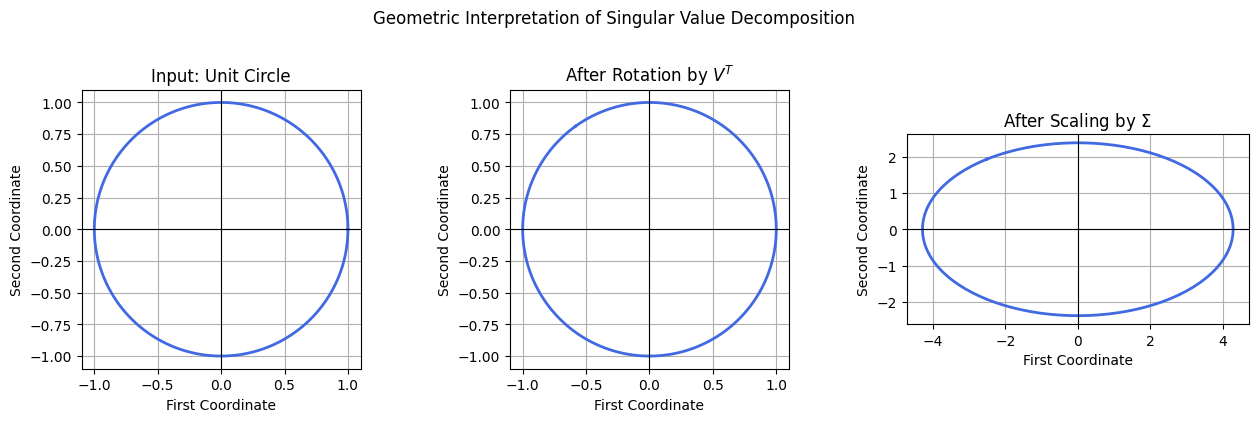

In [21]:
# Visualize the rotation and scaling stages of SVD
theta = np.linspace(0, 2 * np.pi, 200)
unit_circle = np.vstack((np.cos(theta), np.sin(theta)))

rotated_circle = Vt @ unit_circle
scaled_ellipse = Sigma @ rotated_circle

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

stages = [
    (unit_circle, "Input: Unit Circle"),
    (rotated_circle, r"After Rotation by $V^T$"),
    (scaled_ellipse, r"After Scaling by $\Sigma$")
]

for ax, (points, title) in zip(axes, stages):
    ax.plot(points[0], points[1], color="royalblue", linewidth=2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("First Coordinate")
    ax.set_ylabel("Second Coordinate")
    ax.grid()

plt.suptitle("Geometric Interpretation of Singular Value Decomposition", y=1.03)
plt.tight_layout()
plt.show()

The SVD can be interpreted geometrically. The matrix $V^T$ rotates or reflects the input directions, $\Sigma$ stretches them by the singular values, and $U$ maps the result into the output space. The unit circle becomes an ellipse after the singular-value scaling step.

### Section Conclusion
The singular value decomposition successfully factored the matrix into $U$, $\Sigma$, and $V^T$. Multiplying these matrices together reconstructed the original matrix and the orthonormality checks confirmed the properties of $U$ and $V$. The circle-to-ellipse visualization showed how $\Sigma$ stretches the input directions according to the singular values.

## 1.4.2 Low-Rank Matrix Approximations
A low-rank approximation replaces a matrix with a simpler matrix that preserves its most important structure. Using SVD, a k rank approximation is created by keeping only the first k singular values and their corresponding singular vectors:

$$
A_k = U_k \Sigma_k V_k^T.
$$

A smaller value of k produces more compression but may lose more information.

In [22]:
A_low_rank = np.array([
    [6.0, 5.0, 4.0, 3.0],
    [5.0, 4.0, 3.0, 2.0],
    [4.0, 3.0, 2.0, 1.0],
    [3.0, 2.0, 1.0, 0.0]
])

U_lr, s_lr, Vt_lr = np.linalg.svd(A_low_rank)

def rank_k_approximation(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

A_rank_1 = rank_k_approximation(U_lr, s_lr, Vt_lr, 1)
A_rank_2 = rank_k_approximation(U_lr, s_lr, Vt_lr, 2)

rank_1_error = np.linalg.norm(A_low_rank - A_rank_1, "fro")
rank_2_error = np.linalg.norm(A_low_rank - A_rank_2, "fro")

print("Original matrix:")
print(A_low_rank)

print("\nSingular values:")
print(s_lr)

print("\nRank of the original matrix:")
print(np.linalg.matrix_rank(A_low_rank))

print("\nRank-1 approximation:")
print(A_rank_1)

print("\nRank-2 approximation:")
print(A_rank_2)

print("\nRank-1 approximation error:")
print(rank_1_error)

print("\nRank-2 approximation error:")
print(rank_2_error)

print("\nDoes the rank-2 approximation reconstruct the matrix?")
print(np.allclose(A_rank_2, A_low_rank))

Original matrix:
[[6. 5. 4. 3.]
 [5. 4. 3. 2.]
 [4. 3. 2. 1.]
 [3. 2. 1. 0.]]

Singular values:
[13.4833  1.4833  0.      0.    ]

Rank of the original matrix:
2

Rank-1 approximation:
[[6.3408 5.039  3.7372 2.4354]
 [5.039  4.0045 2.9699 1.9354]
 [3.7372 2.9699 2.2027 1.4354]
 [2.4354 1.9354 1.4354 0.9354]]

Rank-2 approximation:
[[ 6.  5.  4.  3.]
 [ 5.  4.  3.  2.]
 [ 4.  3.  2.  1.]
 [ 3.  2.  1. -0.]]

Rank-1 approximation error:
1.4833147735478829

Rank-2 approximation error:
4.058556822502045e-15

Does the rank-2 approximation reconstruct the matrix?
True


### Section Conclusion
The low-rank approximations showed how SVD can simplify a matrix while preserving its major structure. The rank-1 approximation captured the most important pattern but introduced some error. The rank-2 approximation reconstructed this particular matrix almost exactly because the original matrix has rank 2. It is interesting how a seemingly conceptual and abstract concept such as matrix rank demonstrates a very clear numerical difference as well as the tradeoff between compression and accuracy when portraying the matrix as a lower rank.

## 1.4.3 Principal Component Analysis
Principal component analysis, or PCA, reduces the number of variables in a dataset while preserving as much variation as possible.

The main PCA steps are:

1. Center the data by subtracting the mean.
2. Compute the covariance matrix.
3. Find the eigenvalues and eigenvectors of the covariance matrix.
4. Sort the components from greatest to least explained variance.
5. Project the data onto the most important principal components.

For this example, each row represents one observation with two related measurements.

In [23]:
data_pca = np.array([
    [1.0, 1.4],
    [1.5, 2.0],
    [2.2, 2.3],
    [2.8, 3.5],
    [3.1, 3.7],
    [3.9, 4.4],
    [4.2, 5.2],
    [4.9, 5.7]
])

# Center the data
data_mean = np.mean(data_pca, axis=0)
centered_data = data_pca - data_mean

# Covariance matrix
covariance_matrix = np.cov(centered_data, rowvar=False)

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# Sort from largest to smallest eigenvalue
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
principal_components = eigenvectors[:, order]

# Variance explained by each principal component
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Project data onto the principal components
pca_scores = centered_data @ principal_components

print("Original data:")
print(data_pca)

print("\nMean of each feature:")
print(data_mean)

print("\nCovariance matrix:")
print(covariance_matrix)

print("\nEigenvalues:")
print(eigenvalues)

print("\nPrincipal components stored as columns:")
print(principal_components)

print("\nExplained variance ratio:")
print(explained_variance_ratio)

print("\nData projected onto principal components:")
print(pca_scores)

Original data:
[[1.  1.4]
 [1.5 2. ]
 [2.2 2.3]
 [2.8 3.5]
 [3.1 3.7]
 [3.9 4.4]
 [4.2 5.2]
 [4.9 5.7]]

Mean of each feature:
[2.95  3.525]

Covariance matrix:
[[1.8257 2.0671]
 [2.0671 2.3821]]

Eigenvalues:
[4.1897 0.0181]

Principal components stored as columns:
[[ 0.6583 -0.7528]
 [ 0.7528  0.6583]]

Explained variance ratio:
[0.9957 0.0043]

Data projected onto principal components:
[[-2.8833  0.0691]
 [-2.1025  0.0877]
 [-1.4159 -0.2418]
 [-0.1176  0.0965]
 [ 0.2305  0.0023]
 [ 1.284  -0.1392]
 [ 2.0837  0.1616]
 [ 2.9209 -0.0362]]


The first principal component reduces each observation from two values to one PCA score. Using only this component preserves the main direction of variation in the data, but the reconstruction is not identical to the original data. The reconstruction error measures the information lost by reducing the dataset to one dimension, while the explained-variance value shows how much of the original variation PC1 retains.

In [24]:
# Keep only the first principal component
one_component_scores = pca_scores[:, :1]

# Reconstruct the original two-dimensional data from one component
reconstructed_data = (
    one_component_scores @ principal_components[:, :1].T
) + data_mean

reconstruction_error = np.linalg.norm(data_pca - reconstructed_data)

print("One-dimensional PCA scores:")
print(one_component_scores)

print("\nReconstructed data using only PC1:")
print(reconstructed_data)

print("\nReconstruction error:")
print(reconstruction_error)

print("\nVariance preserved by PC1:")
print(explained_variance_ratio[0])

One-dimensional PCA scores:
[[-2.8833]
 [-2.1025]
 [-1.4159]
 [-0.1176]
 [ 0.2305]
 [ 1.284 ]
 [ 2.0837]
 [ 2.9209]]

Reconstructed data using only PC1:
[[1.052  1.3545]
 [1.566  1.9423]
 [2.018  2.4592]
 [2.8726 3.4365]
 [3.1017 3.6985]
 [3.7952 4.4916]
 [4.3216 5.0936]
 [4.8727 5.7238]]

Reconstruction error:
0.3564159475890504

Variance preserved by PC1:
0.9956872406146393


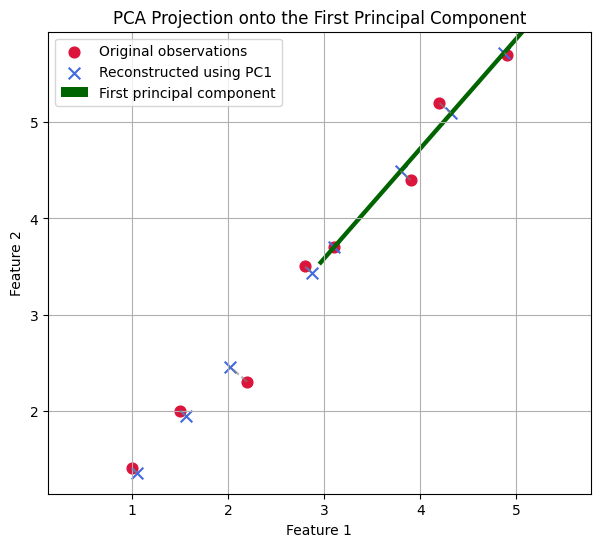

In [25]:
plt.figure(figsize=(7, 6))

plt.scatter(data_pca[:, 0], data_pca[:, 1],
            color="crimson", s=60, label="Original observations")

plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1],
            color="royalblue", marker="x", s=70,
            label="Reconstructed using PC1")

# Show the reconstruction distance for each observation
for original, reconstructed in zip(data_pca, reconstructed_data):
    plt.plot([original[0], reconstructed[0]],
             [original[1], reconstructed[1]],
             color="gray", linestyle="--", alpha=0.6)

# Draw the first principal-component direction
pc1_scale = 2 * np.sqrt(eigenvalues[0])

plt.quiver(
    data_mean[0], data_mean[1],
    principal_components[0, 0] * pc1_scale,
    principal_components[1, 0] * pc1_scale,
    angles="xy", scale_units="xy", scale=1,
    color="darkgreen", width=0.008,
    label="First principal component"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("PCA Projection onto the First Principal Component")
plt.grid()
plt.legend()
plt.axis("equal")
plt.show()

### Section Conclusion
PCA reduced the two-dimensional dataset to one principal component while preserving most of the variation in the data. The first principal component identified the direction with the greatest variance, and the reconstructed points remained close to the original observations. PCA is capable of reducing dimensionality while retaining important information.

## Conclusion / Reflection
Singular value decomposition, low-rank approximation, and principal component analysis connected. SVD breaks a matrix into orthogonal directions and singular values, which makes it possible to identify the most important patterns in the matrix. Low-rank approximation uses only the largest singular values to create a simpler version of a matrix, while PCA uses similar ideas to reduce the number of variables in a dataset.

Now I understand that dimensionality reduction does not always mean losing all useful information. By keeping the strongest components, it is possible to represent a matrix or dataset with fewer dimensions while preserving its main structure.